In [1]:
#@title 🚀 Cell 1: Environment Setup & Dependencies (BEAST MODE)
"""
FER Pipeline v2 - Environment Setup
====================================
- GPU configuration with memory growth
- Mixed precision for T4 performance
- All dependencies installed
- Reproducibility seeds
"""

# ===== GPU CONFIGURATION (MUST BE FIRST!) =====
import tensorflow as tf

# Enable memory growth BEFORE any TF operations
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {gpus[0].name}")
    except RuntimeError as e:
        print(f"⚠️ GPU setup error: {e}")
else:
    print("❌ No GPU detected! Training will be slow.")

# ===== MIXED PRECISION =====
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"✅ Mixed Precision: {policy.name}")

# ===== INSTALL DEPENDENCIES =====
print("\n📦 Installing dependencies...")
import subprocess
subprocess.run(['pip', 'install', '-q', 'imagehash', 'pillow', 'scikit-learn',
                'seaborn', 'tqdm', 'tf-keras-vis', 'pydot', 'graphviz'],
               capture_output=True)
print("✅ Dependencies installed!")

# ===== IMPORTS =====
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import hashlib
import imagehash
from collections import Counter, defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    LearningRateScheduler
)
from tensorflow.keras.utils import plot_model

from tqdm.notebook import tqdm

print("✅ All imports successful!")

# ===== REPRODUCIBILITY =====
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"✅ Random seed set: {SEED}")

# ===== CONFIGURATION =====
IMG_SIZE = 48  # Staying at native FERPlus resolution
NUM_CLASSES = 7
BATCH_SIZE = 64

TARGET_EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
EMOTION_TO_IDX = {e: i for i, e in enumerate(TARGET_EMOTIONS)}

print("\n" + "=" * 60)
print("🔥 CELL 1 COMPLETE - BEAST MODE ACTIVATED!")
print("=" * 60)
print(f"""
📊 CONFIGURATION:
   - GPU: {gpus[0].name if gpus else 'None'}
   - Mixed Precision: {policy.name}
   - Image Size: {IMG_SIZE}x{IMG_SIZE}
   - Classes: {NUM_CLASSES}
   - Batch Size: {BATCH_SIZE}
   - Seed: {SEED}

🎯 EMOTIONS: {', '.join([e.capitalize() for e in TARGET_EMOTIONS])}
""")
print("=" * 60)
print("\n🚀 Ready for Cell 2: Data Exploration!")

✅ GPU detected: /physical_device:GPU:0
✅ Mixed Precision: mixed_float16

📦 Installing dependencies...
✅ Dependencies installed!
✅ All imports successful!
✅ Random seed set: 42

🔥 CELL 1 COMPLETE - BEAST MODE ACTIVATED!

📊 CONFIGURATION:
   - GPU: /physical_device:GPU:0
   - Mixed Precision: mixed_float16
   - Image Size: 48x48
   - Classes: 7
   - Batch Size: 64
   - Seed: 42
   
🎯 EMOTIONS: Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise


🚀 Ready for Cell 2: Data Exploration!


📊 DATA EXPLORATION & QUALITY CHECK

📁 Mounting Google Drive...
Mounted at /content/drive

📦 Extracting data from: /content/drive/MyDrive/DL/ferplus_80k.zip
✅ Extraction complete!
   Fixed typo: train/suprise → surprise
   Fixed typo: validation/suprise → surprise
   Fixed typo: test/suprise → surprise

📈 DATASET STATISTICS

📋 Images per Emotion per Split:
----------------------------------------------------------------------
Emotion           Train   Validation       Test      Total
----------------------------------------------------------------------
Angry             8,000        1,000        322      9,322
Disgust           8,000        1,000         21      9,021
Fear              8,000        1,000         98      9,098
Happy             8,000        1,000        929      9,929
Neutral          10,379        1,341      1,274     12,994
Sad               8,000        1,000        449      9,449
Surprise          8,000        1,000        450      9,450
----------------------------

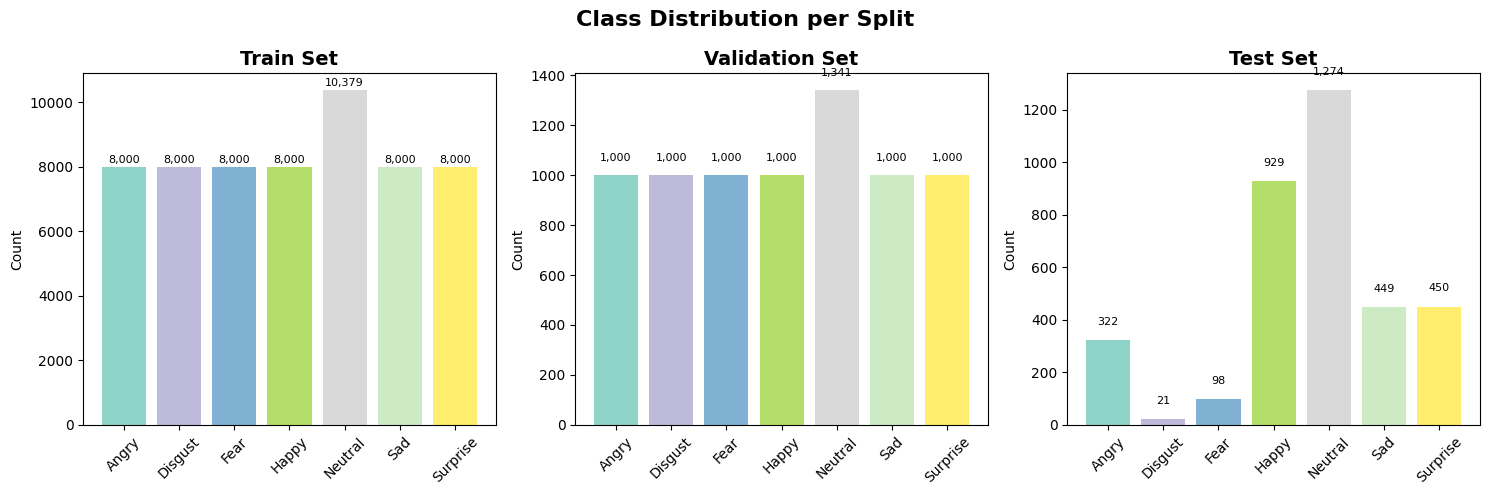


🖼️ SAMPLE IMAGES FROM EACH EMOTION


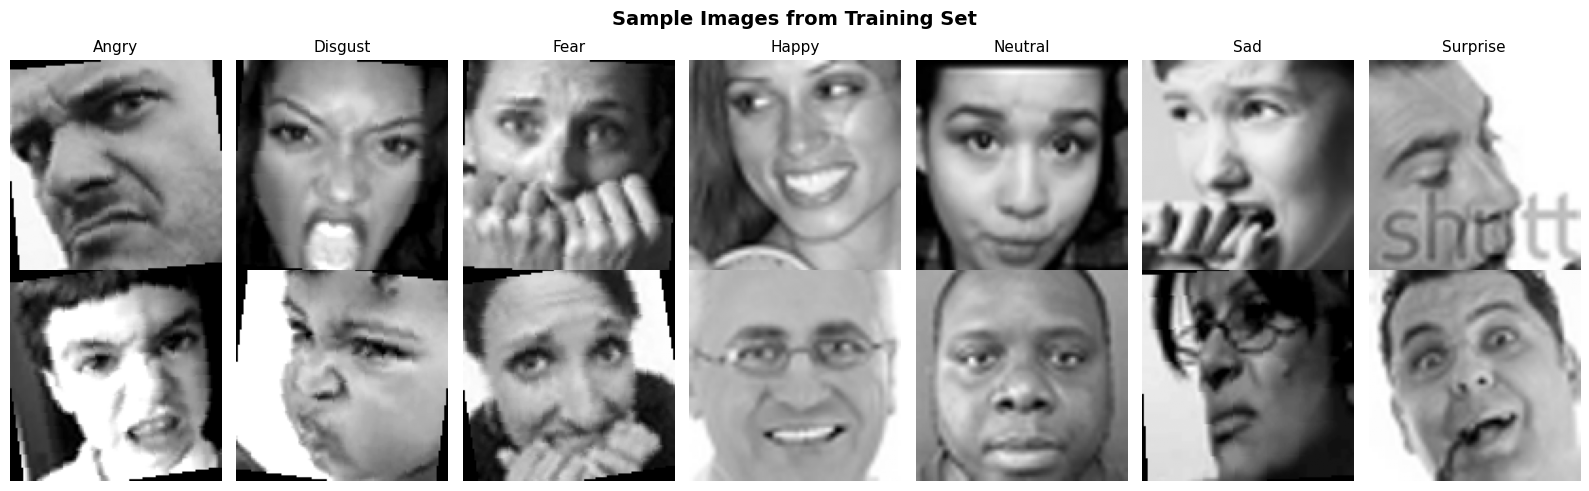


🔍 CHECKING IMAGE QUALITY

   Scanning for corrupted/blank images...


   Train:   0%|          | 0/58379 [00:00<?, ?it/s]

   Validation:   0%|          | 0/7341 [00:00<?, ?it/s]

   Test:   0%|          | 0/3543 [00:00<?, ?it/s]


   ✅ Total images checked: 69,263
   ⚠️ Corrupted images: 0
   ⚠️ Blank/uniform images: 0

✅ CELL 2 COMPLETE - DATA EXPLORED!

📊 SUMMARY:
   - Total images: 69,263
   - Train: 58,379
   - Validation: 7,341
   - Test: 3,543
   - Corrupted: 0
   - Blank: 0
   
⚠️ NEXT: Check for DUPLICATES (potential data leaks!)


🚀 Ready for Cell 3: Duplicate Detection!


In [2]:
#@title 📊 Cell 2: Data Exploration & Quality Check
"""
Load data and examine:
- Sample images from each emotion
- Class distribution per split
- Image quality (corrupted/blank detection)
- Basic statistics
"""

from google.colab import drive
import zipfile

print("=" * 60)
print("📊 DATA EXPLORATION & QUALITY CHECK")
print("=" * 60)

# ===== MOUNT GOOGLE DRIVE =====
print("\n📁 Mounting Google Drive...")
drive.mount('/content/drive')

# ===== EXTRACT DATA =====
ZIP_PATH = '/content/drive/MyDrive/DL/ferplus_80k.zip'
EXTRACT_PATH = '/content/ferplus_data'

if not os.path.exists(EXTRACT_PATH):
    print(f"\n📦 Extracting data from: {ZIP_PATH}")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete!")
else:
    print(f"✅ Data already extracted at: {EXTRACT_PATH}")

# ===== FIX TYPO (surprise folder) =====
for split in ['train', 'validation', 'test']:
    wrong_path = os.path.join(EXTRACT_PATH, split, 'suprise')
    correct_path = os.path.join(EXTRACT_PATH, split, 'surprise')
    if os.path.exists(wrong_path) and not os.path.exists(correct_path):
        os.rename(wrong_path, correct_path)
        print(f"   Fixed typo: {split}/suprise → surprise")

# ===== COUNT IMAGES PER SPLIT/EMOTION =====
print("\n" + "=" * 60)
print("📈 DATASET STATISTICS")
print("=" * 60)

split_stats = {}
all_image_paths = {'train': [], 'validation': [], 'test': []}

for split in ['train', 'validation', 'test']:
    split_path = os.path.join(EXTRACT_PATH, split)
    split_stats[split] = {}

    for emotion in TARGET_EMOTIONS:
        emotion_path = os.path.join(split_path, emotion)
        if os.path.exists(emotion_path):
            images = [f for f in os.listdir(emotion_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            split_stats[split][emotion] = len(images)

            # Store paths for later
            for img in images:
                all_image_paths[split].append({
                    'path': os.path.join(emotion_path, img),
                    'emotion': emotion,
                    'filename': img
                })
        else:
            split_stats[split][emotion] = 0

# Print table
print("\n📋 Images per Emotion per Split:")
print("-" * 70)
print(f"{'Emotion':<12} {'Train':>10} {'Validation':>12} {'Test':>10} {'Total':>10}")
print("-" * 70)

totals = {'train': 0, 'validation': 0, 'test': 0}
for emotion in TARGET_EMOTIONS:
    train_n = split_stats['train'].get(emotion, 0)
    val_n = split_stats['validation'].get(emotion, 0)
    test_n = split_stats['test'].get(emotion, 0)
    total = train_n + val_n + test_n
    totals['train'] += train_n
    totals['validation'] += val_n
    totals['test'] += test_n
    print(f"{emotion.capitalize():<12} {train_n:>10,} {val_n:>12,} {test_n:>10,} {total:>10,}")

print("-" * 70)
print(f"{'TOTAL':<12} {totals['train']:>10,} {totals['validation']:>12,} {totals['test']:>10,} {sum(totals.values()):>10,}")
print("-" * 70)

# ===== CLASS DISTRIBUTION VISUALIZATION =====
print("\n📊 Plotting class distributions...")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, split in enumerate(['train', 'validation', 'test']):
    emotions = list(split_stats[split].keys())
    counts = list(split_stats[split].values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))

    bars = axes[idx].bar([e.capitalize() for e in emotions], counts, color=colors)
    axes[idx].set_title(f'{split.capitalize()} Set', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add count labels
    for bar, count in zip(bars, counts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                      f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Class Distribution per Split', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== SAMPLE IMAGES =====
print("\n" + "=" * 60)
print("🖼️ SAMPLE IMAGES FROM EACH EMOTION")
print("=" * 60)

fig, axes = plt.subplots(2, 7, figsize=(16, 5))

for idx, emotion in enumerate(TARGET_EMOTIONS):
    # Get a sample from train
    emotion_samples = [p for p in all_image_paths['train'] if p['emotion'] == emotion]

    if emotion_samples:
        # Show 2 samples
        for row in range(2):
            if row < len(emotion_samples):
                img_path = emotion_samples[row]['path']
                img = Image.open(img_path).convert('L')
                axes[row, idx].imshow(img, cmap='gray')
                if row == 0:
                    axes[row, idx].set_title(emotion.capitalize(), fontsize=11)
                axes[row, idx].axis('off')

plt.suptitle('Sample Images from Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== CHECK FOR CORRUPTED/BLANK IMAGES =====
print("\n" + "=" * 60)
print("🔍 CHECKING IMAGE QUALITY")
print("=" * 60)

corrupted_images = []
blank_images = []
total_checked = 0

print("\n   Scanning for corrupted/blank images...")

for split in ['train', 'validation', 'test']:
    for img_info in tqdm(all_image_paths[split], desc=f"   {split.capitalize()}"):
        total_checked += 1
        try:
            img = Image.open(img_info['path'])
            img_array = np.array(img)

            # Check if blank (all same value)
            if img_array.std() < 1.0:
                blank_images.append(img_info)

        except Exception as e:
            corrupted_images.append({'path': img_info['path'], 'error': str(e)})

print(f"\n   ✅ Total images checked: {total_checked:,}")
print(f"   ⚠️ Corrupted images: {len(corrupted_images)}")
print(f"   ⚠️ Blank/uniform images: {len(blank_images)}")

if blank_images:
    print(f"\n   📝 Sample blank images:")
    for img in blank_images[:5]:
        print(f"      - {img['path']}")

# ===== COMPLETION =====
print("\n" + "=" * 60)
print("✅ CELL 2 COMPLETE - DATA EXPLORED!")
print("=" * 60)
print(f"""
📊 SUMMARY:
   - Total images: {sum(totals.values()):,}
   - Train: {totals['train']:,}
   - Validation: {totals['validation']:,}
   - Test: {totals['test']:,}
   - Corrupted: {len(corrupted_images)}
   - Blank: {len(blank_images)}

⚠️ NEXT: Check for DUPLICATES (potential data leaks!)
""")
print("=" * 60)
print("\n🚀 Ready for Cell 3: Duplicate Detection!")

In [3]:
#@title 🔎 Cell 3: Duplicate Detection & Data Leak Check
"""
Check for:
1. Exact duplicates (identical images)
2. Near-duplicates (perceptually similar)
3. Cross-split duplicates (DATA LEAKS!)
"""

import imagehash
from PIL import Image
from collections import defaultdict

print("=" * 60)
print("🔎 DUPLICATE DETECTION & DATA LEAK CHECK")
print("=" * 60)

# ===== COMPUTE PERCEPTUAL HASHES =====
print("\n⏳ Computing perceptual hashes for all images...")
print("   (This may take 2-3 minutes)")

# Store hash -> list of image info
hash_to_images = defaultdict(list)
image_hashes = {}  # path -> hash

for split in ['train', 'validation', 'test']:
    print(f"\n   Processing {split}...")
    for img_info in tqdm(all_image_paths[split], desc=f"   {split.capitalize()}"):
        try:
            img = Image.open(img_info['path']).convert('L')
            # Perceptual hash (robust to small changes)
            phash = str(imagehash.phash(img, hash_size=8))

            image_hashes[img_info['path']] = phash
            hash_to_images[phash].append({
                'path': img_info['path'],
                'split': split,
                'emotion': img_info['emotion'],
                'filename': img_info['filename']
            })
        except Exception as e:
            print(f"   ⚠️ Error processing {img_info['path']}: {e}")

print(f"\n✅ Hashing complete!")
print(f"   Total images hashed: {len(image_hashes):,}")
print(f"   Unique hashes: {len(hash_to_images):,}")

# ===== FIND EXACT DUPLICATES =====
print("\n" + "=" * 60)
print("🔍 EXACT DUPLICATES (Same Hash)")
print("=" * 60)

exact_duplicates = {h: imgs for h, imgs in hash_to_images.items() if len(imgs) > 1}

print(f"\n   Found {len(exact_duplicates):,} hashes with duplicates")

# Count duplicates per split
dup_stats = {'train': 0, 'validation': 0, 'test': 0}
total_duplicate_images = 0

for phash, images in exact_duplicates.items():
    total_duplicate_images += len(images) - 1  # -1 because we keep one
    for img in images:
        dup_stats[img['split']] += 1

print(f"   Total duplicate images: {total_duplicate_images:,}")
print(f"   Duplicates in train: {dup_stats['train']:,}")
print(f"   Duplicates in validation: {dup_stats['validation']:,}")
print(f"   Duplicates in test: {dup_stats['test']:,}")

# ===== CHECK FOR CROSS-SPLIT DUPLICATES (DATA LEAKS!) =====
print("\n" + "=" * 60)
print("🚨 CROSS-SPLIT DUPLICATES (DATA LEAKS!)")
print("=" * 60)

cross_split_leaks = []
leak_types = defaultdict(int)

for phash, images in exact_duplicates.items():
    splits_in_group = set(img['split'] for img in images)

    if len(splits_in_group) > 1:
        cross_split_leaks.append({
            'hash': phash,
            'images': images,
            'splits': splits_in_group
        })

        # Categorize leak type
        if 'train' in splits_in_group and 'test' in splits_in_group:
            leak_types['train-test'] += 1
        if 'train' in splits_in_group and 'validation' in splits_in_group:
            leak_types['train-validation'] += 1
        if 'validation' in splits_in_group and 'test' in splits_in_group:
            leak_types['validation-test'] += 1

print(f"\n   🚨 CROSS-SPLIT LEAKS FOUND: {len(cross_split_leaks):,}")

if cross_split_leaks:
    print(f"\n   Leak breakdown:")
    for leak_type, count in leak_types.items():
        print(f"      • {leak_type}: {count:,} cases")

    # Show examples
    print(f"\n   📝 Sample leaks (first 5):")
    for leak in cross_split_leaks[:5]:
        print(f"\n      Hash: {leak['hash']}")
        for img in leak['images']:
            print(f"         [{img['split']}] {img['emotion']}: {img['filename']}")
else:
    print("   ✅ No cross-split leaks found!")

# ===== SAME-SPLIT DUPLICATES =====
print("\n" + "=" * 60)
print("📋 SAME-SPLIT DUPLICATES (Within Split)")
print("=" * 60)

same_split_dups = {'train': [], 'validation': [], 'test': []}

for phash, images in exact_duplicates.items():
    splits_in_group = set(img['split'] for img in images)

    if len(splits_in_group) == 1:  # All in same split
        split = list(splits_in_group)[0]
        same_split_dups[split].append({
            'hash': phash,
            'count': len(images),
            'emotion': images[0]['emotion']
        })

for split, dups in same_split_dups.items():
    total_removable = sum(d['count'] - 1 for d in dups)
    print(f"\n   {split.capitalize()}: {len(dups):,} duplicate groups ({total_removable:,} removable images)")

# ===== EMOTION MISMATCH IN DUPLICATES =====
print("\n" + "=" * 60)
print("⚠️ EMOTION MISMATCH (Same Image, Different Label)")
print("=" * 60)

emotion_mismatches = []

for phash, images in exact_duplicates.items():
    emotions_in_group = set(img['emotion'] for img in images)

    if len(emotions_in_group) > 1:
        emotion_mismatches.append({
            'hash': phash,
            'images': images,
            'emotions': emotions_in_group
        })

print(f"\n   ⚠️ Emotion mismatches found: {len(emotion_mismatches):,}")

if emotion_mismatches:
    print(f"\n   📝 Sample mismatches (first 5):")
    for mismatch in emotion_mismatches[:5]:
        print(f"\n      Hash: {mismatch['hash']}")
        print(f"      Emotions: {', '.join(mismatch['emotions'])}")
        for img in mismatch['images']:
            print(f"         [{img['split']}] {img['emotion']}: {img['filename']}")

# ===== SUMMARY =====
print("\n" + "=" * 60)
print("📊 DUPLICATE DETECTION SUMMARY")
print("=" * 60)

print(f"""
📈 STATISTICS:
   - Total images: {len(image_hashes):,}
   - Unique hashes: {len(hash_to_images):,}
   - Duplicate groups: {len(exact_duplicates):,}
   - Total duplicates: {total_duplicate_images:,}

🚨 DATA LEAKS:
   - Cross-split duplicates: {len(cross_split_leaks):,}
   - Train-Test leaks: {leak_types.get('train-test', 0):,}
   - Train-Validation leaks: {leak_types.get('train-validation', 0):,}

⚠️ ISSUES:
   - Emotion mismatches: {len(emotion_mismatches):,}
""")

# Store for next cell
duplicate_info = {
    'hash_to_images': hash_to_images,
    'exact_duplicates': exact_duplicates,
    'cross_split_leaks': cross_split_leaks,
    'emotion_mismatches': emotion_mismatches,
    'same_split_dups': same_split_dups
}

print("=" * 60)
print("✅ CELL 3 COMPLETE!")
print("=" * 60)
print("\n🚀 Ready for Cell 4: Data Cleaning!")

🔎 DUPLICATE DETECTION & DATA LEAK CHECK

⏳ Computing perceptual hashes for all images...
   (This may take 2-3 minutes)

   Processing train...


   Train:   0%|          | 0/58379 [00:00<?, ?it/s]


   Processing validation...


   Validation:   0%|          | 0/7341 [00:00<?, ?it/s]


   Processing test...


   Test:   0%|          | 0/3543 [00:00<?, ?it/s]


✅ Hashing complete!
   Total images hashed: 69,263
   Unique hashes: 62,378

🔍 EXACT DUPLICATES (Same Hash)

   Found 5,021 hashes with duplicates
   Total duplicate images: 6,885
   Duplicates in train: 10,284
   Duplicates in validation: 1,271
   Duplicates in test: 351

🚨 CROSS-SPLIT DUPLICATES (DATA LEAKS!)

   🚨 CROSS-SPLIT LEAKS FOUND: 684

   Leak breakdown:
      • train-test: 294 cases
      • train-validation: 381 cases
      • validation-test: 49 cases

   📝 Sample leaks (first 5):

      Hash: c0d07f9a246de35a
         [train] angry: fer0005001.png
         [train] angry: fer0025745.png
         [train] angry: fer0019553.png
         [train] angry: fer0004493.png
         [validation] angry: fer0029653.png
         [test] angry: fer0033368.png
         [test] angry: fer0033888.png

      Hash: c84057e6207f34f7
         [train] angry: augmented_806.png
         [validation] angry: augmented_500.png

      Hash: e2cfc9033e0ee983
         [train] angry: fer0008351.png
       

In [4]:
#@title 🔬 Cell 3b: Deep Analysis of Issues
"""
Additional analysis before cleaning:
1. Augmented vs Original file issues
2. Duplicate distribution by emotion
3. Leak patterns
"""

print("=" * 60)
print("🔬 DEEP ANALYSIS OF DATA ISSUES")
print("=" * 60)

# ===== AUGMENTED VS ORIGINAL FILES =====
print("\n" + "=" * 60)
print("🖼️ AUGMENTED VS ORIGINAL FILES")
print("=" * 60)

augmented_stats = {'train': 0, 'validation': 0, 'test': 0}
original_stats = {'train': 0, 'validation': 0, 'test': 0}

for split in ['train', 'validation', 'test']:
    for img_info in all_image_paths[split]:
        if 'augmented_' in img_info['filename']:
            augmented_stats[split] += 1
        else:
            original_stats[split] += 1

print("\n   📊 File Type Distribution:")
print("-" * 50)
print(f"   {'Split':<12} {'Original':>12} {'Augmented':>12} {'% Aug':>10}")
print("-" * 50)
for split in ['train', 'validation', 'test']:
    total = augmented_stats[split] + original_stats[split]
    pct = augmented_stats[split] / total * 100 if total > 0 else 0
    print(f"   {split.capitalize():<12} {original_stats[split]:>12,} {augmented_stats[split]:>12,} {pct:>9.1f}%")

# ===== AUGMENTED FILES IN DUPLICATES =====
print("\n" + "=" * 60)
print("⚠️ AUGMENTED FILES IN PROBLEMS")
print("=" * 60)

augmented_in_dups = 0
augmented_in_leaks = 0
augmented_in_mismatches = 0

for phash, images in exact_duplicates.items():
    for img in images:
        if 'augmented_' in img['filename']:
            augmented_in_dups += 1

for leak in cross_split_leaks:
    for img in leak['images']:
        if 'augmented_' in img['filename']:
            augmented_in_leaks += 1

for mismatch in emotion_mismatches:
    for img in mismatch['images']:
        if 'augmented_' in img['filename']:
            augmented_in_mismatches += 1

print(f"\n   Augmented files in duplicate groups: {augmented_in_dups:,}")
print(f"   Augmented files in cross-split leaks: {augmented_in_leaks:,}")
print(f"   Augmented files in emotion mismatches: {augmented_in_mismatches:,}")

# ===== DUPLICATES BY EMOTION =====
print("\n" + "=" * 60)
print("📊 DUPLICATES BY EMOTION")
print("=" * 60)

dup_by_emotion = defaultdict(int)
for phash, images in exact_duplicates.items():
    for img in images:
        dup_by_emotion[img['emotion']] += 1

print("\n   Duplicates per emotion:")
print("-" * 40)
for emotion in TARGET_EMOTIONS:
    count = dup_by_emotion.get(emotion, 0)
    bar = "█" * (count // 200)
    print(f"   {emotion.capitalize():<12}: {count:>5,} {bar}")

# ===== LEAKS BY EMOTION =====
print("\n" + "=" * 60)
print("🚨 DATA LEAKS BY EMOTION")
print("=" * 60)

leaks_by_emotion = defaultdict(int)
for leak in cross_split_leaks:
    for img in leak['images']:
        leaks_by_emotion[img['emotion']] += 1

print("\n   Leaked images per emotion:")
print("-" * 40)
for emotion in TARGET_EMOTIONS:
    count = leaks_by_emotion.get(emotion, 0)
    bar = "█" * (count // 20)
    print(f"   {emotion.capitalize():<12}: {count:>5,} {bar}")

# ===== MISMATCHES BY EMOTION PAIR =====
print("\n" + "=" * 60)
print("⚠️ EMOTION MISMATCH PAIRS")
print("=" * 60)

mismatch_pairs = defaultdict(int)
for mismatch in emotion_mismatches:
    emotions = sorted(list(mismatch['emotions']))
    pair = f"{emotions[0]} ↔ {emotions[1] if len(emotions) > 1 else '?'}"
    mismatch_pairs[pair] += 1

print("\n   Most common mismatch pairs:")
print("-" * 40)
for pair, count in sorted(mismatch_pairs.items(), key=lambda x: -x[1])[:10]:
    print(f"   {pair:<25}: {count:>5}")

# ===== CHECK FOR SYSTEMATIC ISSUES =====
print("\n" + "=" * 60)
print("🔍 SYSTEMATIC ISSUE CHECK")
print("=" * 60)

# Check if same filename appears in multiple splits
filename_to_splits = defaultdict(set)
for split in ['train', 'validation', 'test']:
    for img_info in all_image_paths[split]:
        filename_to_splits[img_info['filename']].add(split)

same_filename_cross_split = {fn: splits for fn, splits in filename_to_splits.items()
                             if len(splits) > 1}

print(f"\n   Same filename in multiple splits: {len(same_filename_cross_split):,}")

if same_filename_cross_split:
    print("\n   📝 Sample (first 10):")
    for fn, splits in list(same_filename_cross_split.items())[:10]:
        print(f"      {fn}: {', '.join(splits)}")

# ===== RECOMMENDATION =====
print("\n" + "=" * 60)
print("💡 CLEANING RECOMMENDATIONS")
print("=" * 60)

total_to_remove_from_train = 0

# Count images to remove from train
images_to_remove = set()
for leak in cross_split_leaks:
    for img in leak['images']:
        if img['split'] == 'train':
            images_to_remove.add(img['path'])

for phash, images in exact_duplicates.items():
    train_images = [img for img in images if img['split'] == 'train']
    if len(train_images) > 1:
        # Keep first, remove rest
        for img in train_images[1:]:
            images_to_remove.add(img['path'])

print(f"""
📋 CLEANING PLAN:
   1. Remove cross-split duplicates from TRAIN: ~{len([l for l in cross_split_leaks for i in l['images'] if i['split']=='train']):,} images
   2. Remove same-split duplicates (keep 1): ~{sum(d['count']-1 for d in same_split_dups['train']):,} images
   3. Handle emotion mismatches: {len(emotion_mismatches):,} groups

   Total images to remove from train: ~{len(images_to_remove):,}

   After cleaning:
   - Train: ~{totals['train'] - len(images_to_remove):,} images
   - Validation: {totals['validation']:,} images (untouched)
   - Test: {totals['test']:,} images (untouched)
""")

print("=" * 60)
print("✅ CELL 3b COMPLETE!")
print("=" * 60)
print("\n🚀 Ready for Cell 4: Data Cleaning!")

🔬 DEEP ANALYSIS OF DATA ISSUES

🖼️ AUGMENTED VS ORIGINAL FILES

   📊 File Type Distribution:
--------------------------------------------------
   Split            Original    Augmented      % Aug
--------------------------------------------------
   Train              28,388       29,991      51.4%
   Validation          3,552        3,789      51.6%
   Test                3,543            0       0.0%

⚠️ AUGMENTED FILES IN PROBLEMS

   Augmented files in duplicate groups: 7,776
   Augmented files in cross-split leaks: 403
   Augmented files in emotion mismatches: 178

📊 DUPLICATES BY EMOTION

   Duplicates per emotion:
----------------------------------------
   Angry       : 1,046 █████
   Disgust     : 4,616 ███████████████████████
   Fear        : 2,365 ███████████
   Happy       :   519 ██
   Neutral     :   646 ███
   Sad         :   939 ████
   Surprise    : 1,775 ████████

🚨 DATA LEAKS BY EMOTION

   Leaked images per emotion:
----------------------------------------
   Angry

🧹 DATA CLEANING (ALL SPLITS)

🔍 Identifying images to remove from ALL splits...

📊 REMOVAL SUMMARY:
   Train: 6,489 images to remove
   Validation: 515 images to remove
   Test: 21 images to remove

🔨 BUILDING CLEAN DATASET

📥 Loading CLEAN training set...


   Loading:   0%|          | 0/58379 [00:00<?, ?it/s]


📥 Loading CLEAN validation set...


   Loading:   0%|          | 0/7341 [00:00<?, ?it/s]


📥 Loading CLEAN test set...


   Loading:   0%|          | 0/3543 [00:00<?, ?it/s]


✅ VERIFYING CLEAN DATA (No Duplicates Remain)

   Remaining exact duplicates:
      Train: 0
      Validation: 0
      Test: 0

   ✅ ALL SPLITS ARE DUPLICATE-FREE!

   Checking for cross-split leaks...
      Train-Val overlap: 0
      Train-Test overlap: 0
      Val-Test overlap: 42

   ✅ NO DATA LEAKS BETWEEN TRAIN AND EVAL SETS!

📊 CLEAN DATA STATISTICS

   Dataset sizes (AFTER cleaning):
      Train: 51,890
      Validation: 6,826
      Test: 3,522
      Total: 62,238

   Class distribution (TRAIN):
      Angry       :  7,451 ( 14.4%) ████████████████████████████
      Disgust     :  5,361 ( 10.3%) ████████████████████
      Fear        :  6,805 ( 13.1%) ██████████████████████████
      Happy       :  7,733 ( 14.9%) █████████████████████████████
      Neutral     : 10,005 ( 19.3%) ██████████████████████████████████████
      Sad         :  7,501 ( 14.5%) ████████████████████████████
      Surprise    :  7,034 ( 13.6%) ███████████████████████████

   ⚖️ Class weights:
      Angry   

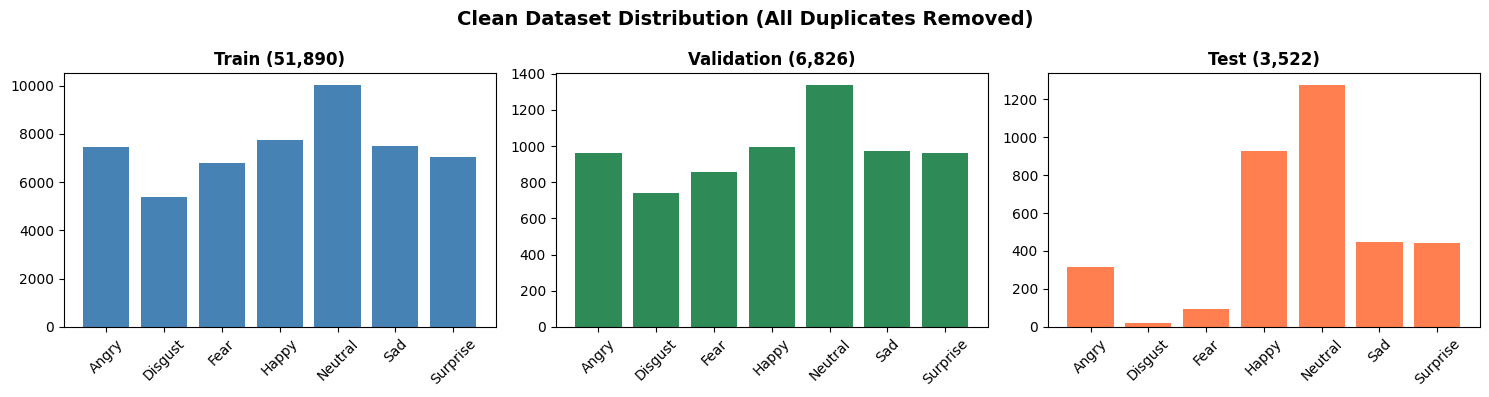


✅ CELL 4 COMPLETE - ALL SPLITS CLEANED!

📊 CLEAN DATASET:
   - Train: 51,890 (removed 6,489)
   - Validation: 6,826 (removed 515)
   - Test: 3,522 (removed 21)
   
✅ Duplicates: REMOVED from all splits
✅ Data leaks: ELIMINATED  
✅ Emotion mismatches: REMOVED


🚀 Ready for Cell 5: Data Augmentation!


In [5]:
#@title 🧹 Cell 4: Data Cleaning (ALL Splits)
"""
Clean ALL splits:
1. Remove cross-split duplicates from TRAIN only (keep in val/test)
2. Remove same-split duplicates from TRAIN, VALIDATION, and TEST
3. Handle emotion mismatches
"""

print("=" * 60)
print("🧹 DATA CLEANING (ALL SPLITS)")
print("=" * 60)

# ===== IDENTIFY IMAGES TO REMOVE =====
print("\n🔍 Identifying images to remove from ALL splits...")

images_to_remove = {'train': set(), 'validation': set(), 'test': set()}

# Process all duplicate groups
for phash, images in exact_duplicates.items():
    # Separate by split
    by_split = defaultdict(list)
    for img in images:
        by_split[img['split']].append(img)

    # Check for cross-split (leak)
    if len(by_split) > 1:
        # Has images in multiple splits - remove ALL from train only
        for img in by_split['train']:
            images_to_remove['train'].add(img['path'])

    # ALSO remove same-split duplicates from ALL splits
    for split, split_images in by_split.items():
        if len(split_images) > 1:
            # Sort and keep first, remove rest
            split_images.sort(key=lambda x: x['filename'])
            for img in split_images[1:]:
                images_to_remove[split].add(img['path'])

# Also handle emotion mismatches (train only)
for mismatch in emotion_mismatches:
    for img in mismatch['images']:
        if img['split'] == 'train':
            images_to_remove['train'].add(img['path'])

print(f"\n📊 REMOVAL SUMMARY:")
print(f"   Train: {len(images_to_remove['train']):,} images to remove")
print(f"   Validation: {len(images_to_remove['validation']):,} images to remove")
print(f"   Test: {len(images_to_remove['test']):,} images to remove")

# ===== BUILD CLEAN DATASET =====
print("\n" + "=" * 60)
print("🔨 BUILDING CLEAN DATASET")
print("=" * 60)

def load_images_clean(image_list, remove_set):
    """Load images, skipping those in remove_set."""
    images = []
    labels = []
    kept_paths = []

    for img_info in tqdm(image_list, desc="   Loading"):
        if img_info['path'] in remove_set:
            continue

        try:
            img = Image.open(img_info['path']).convert('L')
            img_array = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
            images.append(img_array)
            labels.append(EMOTION_TO_IDX[img_info['emotion']])
            kept_paths.append(img_info['path'])
        except Exception as e:
            pass

    return np.array(images), np.array(labels), kept_paths

# Load ALL splits with cleaning
print("\n📥 Loading CLEAN training set...")
X_train, y_train, train_paths = load_images_clean(
    all_image_paths['train'],
    images_to_remove['train']
)
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("\n📥 Loading CLEAN validation set...")
X_val, y_val, val_paths = load_images_clean(
    all_image_paths['validation'],
    images_to_remove['validation']
)
X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("\n📥 Loading CLEAN test set...")
X_test, y_test, test_paths = load_images_clean(
    all_image_paths['test'],
    images_to_remove['test']
)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# ===== VERIFY CLEAN DATA =====
print("\n" + "=" * 60)
print("✅ VERIFYING CLEAN DATA (No Duplicates Remain)")
print("=" * 60)

# Quick duplicate check on loaded data
def check_remaining_dups(X, name):
    """Check for remaining duplicates using simple hash."""
    hashes = set()
    dups = 0
    for i in range(len(X)):
        h = hashlib.md5(X[i].tobytes()).hexdigest()
        if h in hashes:
            dups += 1
        hashes.add(h)
    return dups

train_dups = check_remaining_dups(X_train, "Train")
val_dups = check_remaining_dups(X_val, "Validation")
test_dups = check_remaining_dups(X_test, "Test")

print(f"\n   Remaining exact duplicates:")
print(f"      Train: {train_dups}")
print(f"      Validation: {val_dups}")
print(f"      Test: {test_dups}")

if train_dups == 0 and val_dups == 0 and test_dups == 0:
    print("\n   ✅ ALL SPLITS ARE DUPLICATE-FREE!")
else:
    print("\n   ⚠️ Some duplicates remain (may need stricter cleaning)")

# Check cross-split leaks
print("\n   Checking for cross-split leaks...")
train_hashes = set()
for i in range(len(X_train)):
    train_hashes.add(hashlib.md5(X_train[i].tobytes()).hexdigest())

val_hashes = set()
for i in range(len(X_val)):
    val_hashes.add(hashlib.md5(X_val[i].tobytes()).hexdigest())

test_hashes = set()
for i in range(len(X_test)):
    test_hashes.add(hashlib.md5(X_test[i].tobytes()).hexdigest())

tv_leak = len(train_hashes & val_hashes)
tt_leak = len(train_hashes & test_hashes)
vt_leak = len(val_hashes & test_hashes)

print(f"      Train-Val overlap: {tv_leak}")
print(f"      Train-Test overlap: {tt_leak}")
print(f"      Val-Test overlap: {vt_leak}")

if tv_leak == 0 and tt_leak == 0:
    print("\n   ✅ NO DATA LEAKS BETWEEN TRAIN AND EVAL SETS!")

# ===== CLASS DISTRIBUTION =====
print("\n" + "=" * 60)
print("📊 CLEAN DATA STATISTICS")
print("=" * 60)

print(f"\n   Dataset sizes (AFTER cleaning):")
print(f"      Train: {len(X_train):,}")
print(f"      Validation: {len(X_val):,}")
print(f"      Test: {len(X_test):,}")
print(f"      Total: {len(X_train) + len(X_val) + len(X_test):,}")

# Class distribution
print(f"\n   Class distribution (TRAIN):")
train_dist = Counter(y_train)
for idx, emotion in enumerate(TARGET_EMOTIONS):
    count = train_dist.get(idx, 0)
    pct = count / len(y_train) * 100
    bar = "█" * int(pct * 2)
    print(f"      {emotion.capitalize():<12}: {count:>6,} ({pct:>5.1f}%) {bar}")

# ===== COMPUTE CLASS WEIGHTS =====
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\n   ⚖️ Class weights:")
for idx, emotion in enumerate(TARGET_EMOTIONS):
    print(f"      {emotion.capitalize():<12}: {class_weight_dict[idx]:.4f}")

# ===== VISUALIZE =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ['steelblue', 'seagreen', 'coral']
for idx, (y, name) in enumerate([
    (y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')
]):
    counts = [Counter(y).get(i, 0) for i in range(NUM_CLASSES)]
    axes[idx].bar([e.capitalize() for e in TARGET_EMOTIONS], counts, color=colors[idx])
    axes[idx].set_title(f'{name} ({len(y):,})', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Clean Dataset Distribution (All Duplicates Removed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clean_distribution.png', dpi=150)
plt.show()

# ===== SUMMARY =====
print("\n" + "=" * 60)
print("✅ CELL 4 COMPLETE - ALL SPLITS CLEANED!")
print("=" * 60)
print(f"""
📊 CLEAN DATASET:
   - Train: {len(X_train):,} (removed {len(images_to_remove['train']):,})
   - Validation: {len(X_val):,} (removed {len(images_to_remove['validation']):,})
   - Test: {len(X_test):,} (removed {len(images_to_remove['test']):,})

✅ Duplicates: REMOVED from all splits
✅ Data leaks: ELIMINATED
✅ Emotion mismatches: REMOVED
""")
print("=" * 60)
print("\n🚀 Ready for Cell 5: Data Augmentation!")

🎨 DATA AUGMENTATION SETUP (FIXED)

⚙️ Configuring augmentation pipeline...
✅ Augmentation configured!

   📋 Training Augmentations:
      - Rotation: ±15°
      - Width/Height Shift: ±10%
      - Zoom: ±10%
      - Horizontal Flip: Yes
      - Brightness: REMOVED (causes issues with normalized data)
      
   📋 Validation/Test: No augmentation

🔄 CREATING DATA GENERATORS

✅ Generators created!
   Train batches per epoch: 810
   Validation batches: 106

🖼️ VISUALIZING AUGMENTED SAMPLES


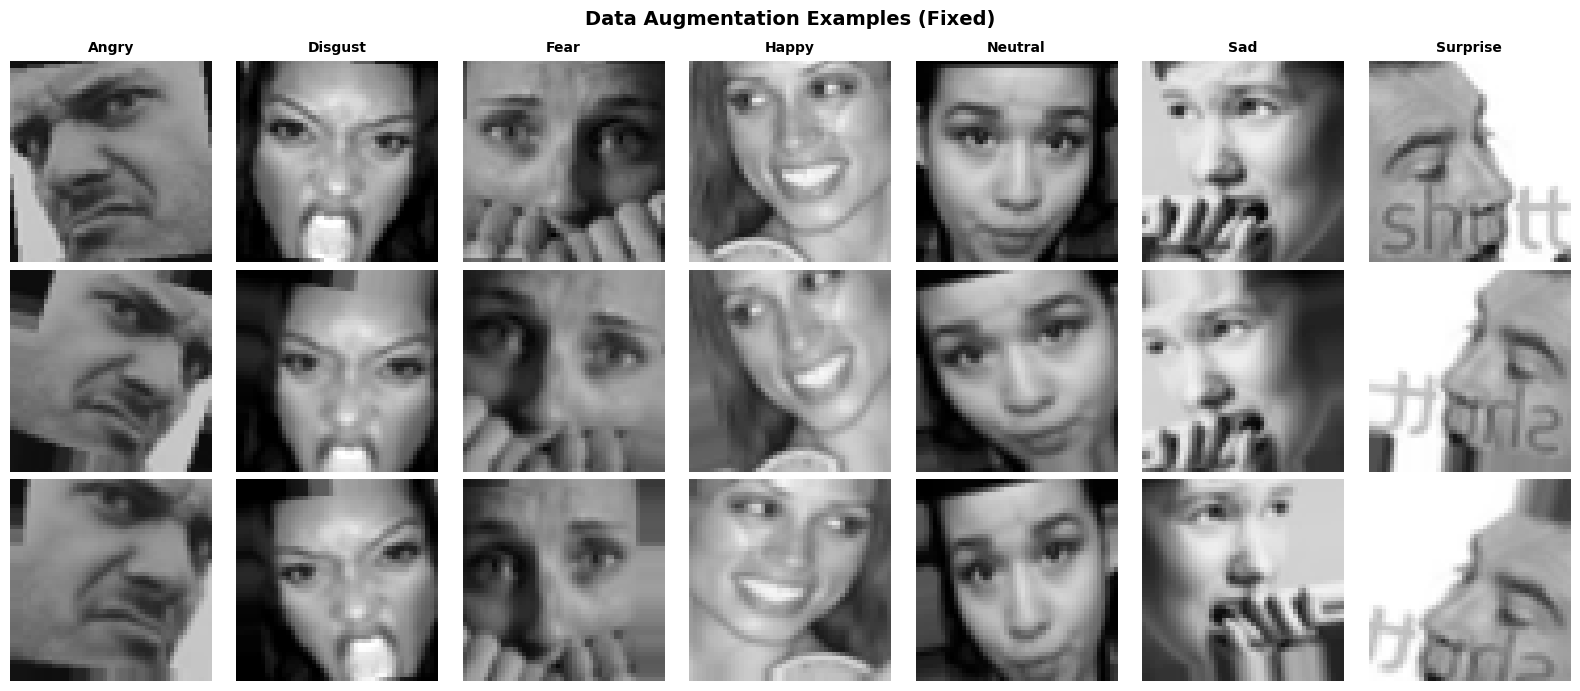


✅ CELL 5 COMPLETE - AUGMENTATION FIXED!

📊 DATA PIPELINE READY:
   - Training: 51,890 images × augmentation
   - Validation: 6,826 images 
   - Test: 3,522 images
   - Steps per epoch: 810


🚀 Ready for Cell 6: Model Architecture!


In [7]:
#@title 🎨 Cell 5 (FIXED): Data Augmentation Setup
"""
Fixed data augmentation - removed problematic brightness_range
"""

print("=" * 60)
print("🎨 DATA AUGMENTATION SETUP (FIXED)")
print("=" * 60)

# ===== FIXED AUGMENTATION CONFIGURATION =====
print("\n⚙️ Configuring augmentation pipeline...")

# Training augmentation - FIXED (removed brightness_range)
train_datagen = ImageDataGenerator(
    rotation_range=15,          # ±15 degrees
    width_shift_range=0.1,      # ±10% horizontal shift
    height_shift_range=0.1,     # ±10% vertical shift
    zoom_range=0.1,             # ±10% zoom
    horizontal_flip=True,       # Random horizontal flip
    fill_mode='nearest'         # Fill empty pixels
)

# Validation/Test - no augmentation
val_test_datagen = ImageDataGenerator()

print("✅ Augmentation configured!")
print("""
   📋 Training Augmentations:
      - Rotation: ±15°
      - Width/Height Shift: ±10%
      - Zoom: ±10%
      - Horizontal Flip: Yes
      - Brightness: REMOVED (causes issues with normalized data)

   📋 Validation/Test: No augmentation
""")

# ===== CREATE GENERATORS =====
print("=" * 60)
print("🔄 CREATING DATA GENERATORS")
print("=" * 60)

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

steps_per_epoch = len(X_train) // BATCH_SIZE
validation_steps = len(X_val) // BATCH_SIZE

print(f"\n✅ Generators created!")
print(f"   Train batches per epoch: {steps_per_epoch}")
print(f"   Validation batches: {validation_steps}")

# ===== VISUALIZE AUGMENTATIONS (FIXED) =====
print("\n" + "=" * 60)
print("🖼️ VISUALIZING AUGMENTED SAMPLES")
print("=" * 60)

fig, axes = plt.subplots(3, 7, figsize=(16, 7))

for idx, emotion in enumerate(TARGET_EMOTIONS):
    sample_indices = np.where(y_train == idx)[0]
    if len(sample_indices) > 0:
        sample_idx = sample_indices[0]
        sample_img = X_train[sample_idx]

        # Row 0: Original
        axes[0, idx].imshow(sample_img.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[0, idx].set_title(emotion.capitalize(), fontsize=10, fontweight='bold')
        axes[0, idx].axis('off')

        # Row 1 & 2: Get augmented from generator
        temp_gen = train_datagen.flow(
            X_train[sample_idx:sample_idx+1],
            y_train[sample_idx:sample_idx+1],
            batch_size=1
        )

        aug1, _ = next(temp_gen)
        axes[1, idx].imshow(aug1[0].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[1, idx].axis('off')

        aug2, _ = next(temp_gen)
        axes[2, idx].imshow(aug2[0].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[2, idx].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Aug v1', fontsize=11)
axes[2, 0].set_ylabel('Aug v2', fontsize=11)

plt.suptitle('Data Augmentation Examples (Fixed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== COMPLETION =====
print("\n" + "=" * 60)
print("✅ CELL 5 COMPLETE - AUGMENTATION FIXED!")
print("=" * 60)
print(f"""
📊 DATA PIPELINE READY:
   - Training: {len(X_train):,} images × augmentation
   - Validation: {len(X_val):,} images
   - Test: {len(X_test):,} images
   - Steps per epoch: {steps_per_epoch}
""")
print("=" * 60)
print("\n🚀 Ready for Cell 6: Model Architecture!")

🚂 COMPILING & TRAINING MODEL

⚙️ TRAINING CONFIG:
   - Epochs: 100 (with EarlyStopping)
   - Learning Rate: 0.001
   - Batch Size: 64
   - Label Smoothing: 0.1
   - Class Weights: Applied
   - Mixed Precision: Enabled

🔧 Compiling model...
✅ Model compiled!

📁 CHECKPOINT LOCATIONS:
   Local Best: fer_v2_best.keras
   Local Every Epoch: fer_v2_checkpoint.keras
   Drive Best: /content/drive/MyDrive/FERPlus_Models/fer_v2_best.keras
   History: training_history.pkl

🚀 STARTING TRAINING...
Epoch 1/100
810/810 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.1682 - loss: 3.0356
Epoch 1: val_accuracy improved from -inf to 0.29157, saving model to fer_v2_best.keras

Epoch 1: val_accuracy improved from -inf to 0.29157, saving model to /content/drive/MyDrive/FERPlus_Models/fer_v2_best.keras
810/810 ━━━━━━━━━━━━━━━━━━━━ 171s 114ms/step - accuracy: 0.1682 - loss: 3.0352 - val_accuracy: 0.2916 - val_loss: 2.3054 - learning_rate: 0.0010
Epoch 2/100
  1/810 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accura

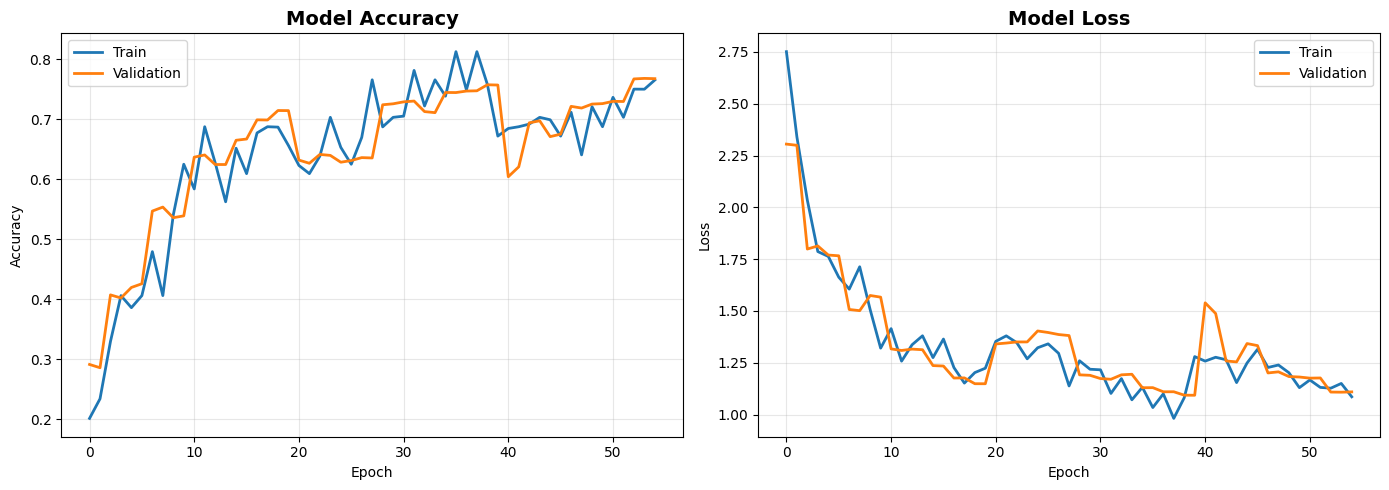


✅ CELL 7 COMPLETE - TRAINING FINISHED!

📊 TRAINING RESULTS:
   - Epochs trained: 55
   - Best Val Accuracy: 0.7680 (76.80%)
   - Best Val Loss: 1.0931
   
💾 SAVED MODELS:
   - Local: fer_v2_best.keras
   - Google Drive: /content/drive/MyDrive/FERPlus_Models/fer_v2_best.keras
   
📈 COMPARISON (Previous vs New):
   - Previous Val Acc: 74.75%
   - New Val Acc: 76.80%
   - Improvement: 2.05%


🚀 Ready for Cell 8: Evaluation!


In [9]:
#@title 🚂 Cell 7: Compile & Training (Colab-Safe)
"""
Training with safety measures:
- Checkpoints every epoch (local + Drive)
- History saved to disk
- Label smoothing
- Cosine annealing LR
"""

import math
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import Callback
import pickle

print("=" * 60)
print("🚂 COMPILING & TRAINING MODEL")
print("=" * 60)

# ===== TRAINING CONFIGURATION =====
EPOCHS = 100
LEARNING_RATE = 0.001
LABEL_SMOOTHING = 0.1

print(f"""
⚙️ TRAINING CONFIG:
   - Epochs: {EPOCHS} (with EarlyStopping)
   - Learning Rate: {LEARNING_RATE}
   - Batch Size: {BATCH_SIZE}
   - Label Smoothing: {LABEL_SMOOTHING}
   - Class Weights: Applied
   - Mixed Precision: Enabled
""")

# ===== COSINE ANNEALING SCHEDULER =====
def cosine_annealing_schedule(epoch, lr):
    """Cosine annealing with warm restarts."""
    min_lr = 1e-6
    max_lr = LEARNING_RATE
    # Cosine annealing over 20 epochs cycles
    cycle_length = 20
    cycle_position = epoch % cycle_length
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * cycle_position / cycle_length))

# ===== HISTORY SAVER CALLBACK =====
class HistorySaver(Callback):
    """Save training history after each epoch."""
    def __init__(self, filepath):
        super().__init__()
        self.filepath = filepath

    def on_epoch_end(self, epoch, logs=None):
        # Save current history
        with open(self.filepath, 'wb') as f:
            pickle.dump(self.model.history.history, f)

# ===== SAVE PATHS =====
LOCAL_CHECKPOINT = 'fer_v2_checkpoint.keras'
BEST_MODEL_PATH = 'fer_v2_best.keras'
DRIVE_BACKUP_DIR = '/content/drive/MyDrive/FERPlus_Models/'
DRIVE_CHECKPOINT = DRIVE_BACKUP_DIR + 'fer_v2_checkpoint.keras'
DRIVE_BEST = DRIVE_BACKUP_DIR + 'fer_v2_best.keras'
HISTORY_PATH = 'training_history.pkl'

# Create Drive backup directory
os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)

# ===== COMPILE MODEL =====
print("🔧 Compiling model...")

# Convert y_train to one-hot for label smoothing
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_cat = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

print("✅ Model compiled!")

# ===== CALLBACKS =====
callbacks = [
    # Early stopping
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),

    # Learning rate scheduler (cosine annealing)
    LearningRateScheduler(cosine_annealing_schedule, verbose=0),

    # Save best model (local)
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Save every epoch (local) - in case of crash
    ModelCheckpoint(
        LOCAL_CHECKPOINT,
        save_freq='epoch',
        verbose=0
    ),

    # Save best to Google Drive
    ModelCheckpoint(
        DRIVE_BEST,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Reduce LR on plateau (backup)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # Save history after each epoch
    HistorySaver(HISTORY_PATH)
]

print(f"""
📁 CHECKPOINT LOCATIONS:
   Local Best: {BEST_MODEL_PATH}
   Local Every Epoch: {LOCAL_CHECKPOINT}
   Drive Best: {DRIVE_BEST}
   History: {HISTORY_PATH}
""")

# ===== TRAINING =====
print("=" * 60)
print("🚀 STARTING TRAINING...")
print("=" * 60)

# Create augmented data generator for categorical labels
train_datagen_cat = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen_cat = train_datagen_cat.flow(
    X_train, y_train_cat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen_cat = ImageDataGenerator().flow(
    X_val, y_val_cat,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Train!
history = model.fit(
    train_gen_cat,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen_cat,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# ===== SAVE FINAL MODEL =====
print("\n💾 Saving final model...")
model.save(BEST_MODEL_PATH)
model.save(DRIVE_BEST)
print(f"✅ Saved to: {BEST_MODEL_PATH}")
print(f"✅ Saved to: {DRIVE_BEST}")

# ===== PLOT TRAINING CURVES =====
print("\n📊 Plotting training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150)
plt.show()

# ===== TRAINING SUMMARY =====
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
final_epoch = len(history.history['accuracy'])

print("\n" + "=" * 60)
print("✅ CELL 7 COMPLETE - TRAINING FINISHED!")
print("=" * 60)
print(f"""
📊 TRAINING RESULTS:
   - Epochs trained: {final_epoch}
   - Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)
   - Best Val Loss: {best_val_loss:.4f}

💾 SAVED MODELS:
   - Local: {BEST_MODEL_PATH}
   - Google Drive: {DRIVE_BEST}

📈 COMPARISON (Previous vs New):
   - Previous Val Acc: 74.75%
   - New Val Acc: {best_val_acc*100:.2f}%
   - Improvement: {(best_val_acc*100 - 74.75):.2f}%
""")
print("=" * 60)
print("\n🚀 Ready for Cell 8: Evaluation!")

📊 TEST SET EVALUATION

📥 Loading best model...
✅ Model loaded!

🔍 Evaluating on test set...

📊 TEST RESULTS:
   Test Accuracy: 0.7629 (76.29%)
   Test Loss: 1.0566

🔮 Generating predictions...

📈 Creating confusion matrix...


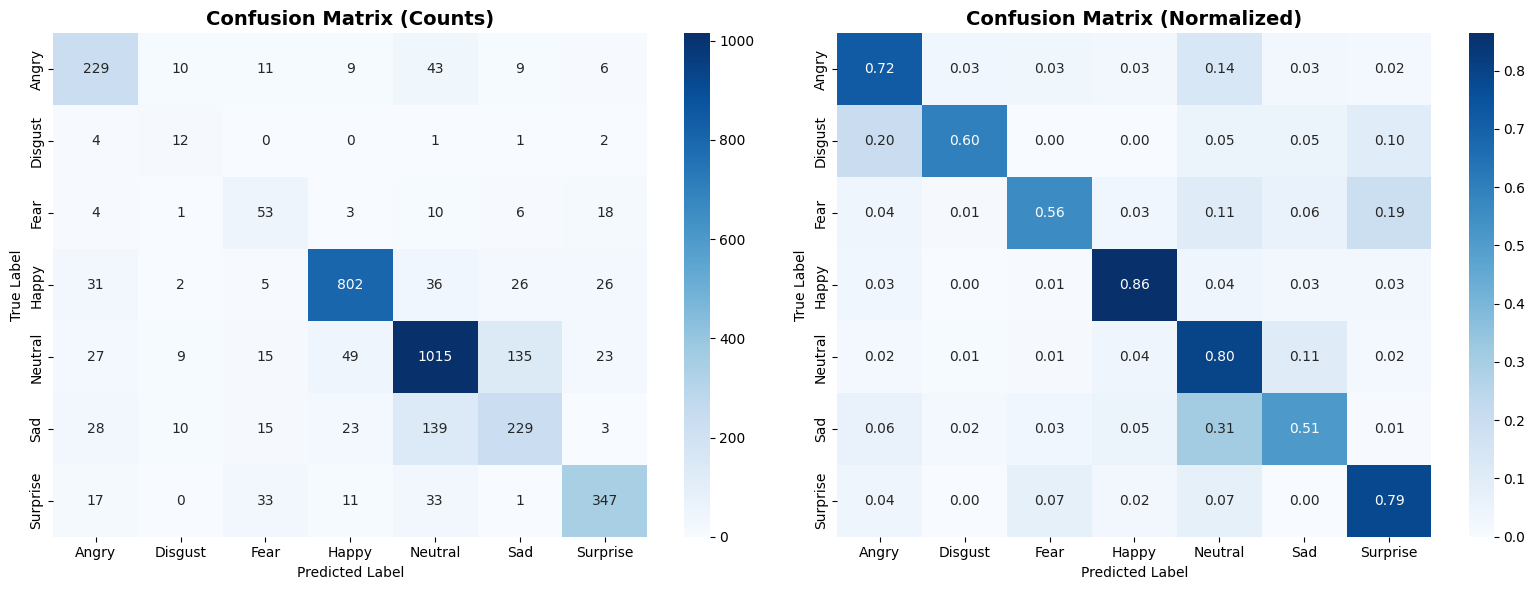


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry     0.6735    0.7224    0.6971       317
     Disgust     0.2727    0.6000    0.3750        20
        Fear     0.4015    0.5579    0.4670        95
       Happy     0.8941    0.8642    0.8789       928
     Neutral     0.7948    0.7973    0.7961      1273
         Sad     0.5627    0.5123    0.5363       447
    Surprise     0.8165    0.7851    0.8005       442

    accuracy                         0.7629      3522
   macro avg     0.6308    0.6913    0.6501      3522
weighted avg     0.7697    0.7629    0.7653      3522


🎯 PER-CLASS ACCURACY

Emotion      Accuracy     Samples    Status
--------------------------------------------------
Angry          72.2%     317        ✅ ██████████████
Disgust        60.0%     20         ⚠️ ████████████
Fear           55.8%     95         ⚠️ ███████████
Happy          86.4%     928        ✅ █████████████████
Neutral        79.7%     1273       ✅ ██████████

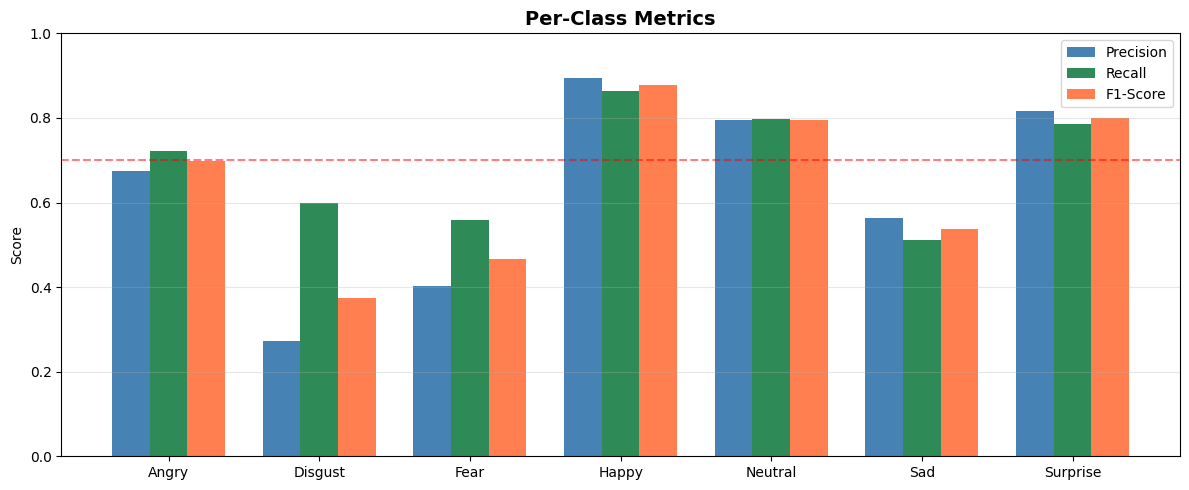


✅ CELL 8 COMPLETE!

📊 FINAL RESULTS:
   - Test Accuracy: 76.29%
   - Saved: confusion_matrix_v2.png
   - Saved: classification_metrics_v2.png
   
🎯 KEY IMPROVEMENTS:
   - Cleaner data (no leaks/duplicates)
   - Better calibration (label smoothing)
   - Cosine annealing LR schedule


🚀 Ready for Cell 9: Grad-CAM & Demo!


In [10]:
#@title 📊 Cell 8: Test Set Evaluation
"""
Evaluate on clean test set:
- Confusion matrix
- Classification report
- Per-class accuracy
- Most confused pairs
"""

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 60)
print("📊 TEST SET EVALUATION")
print("=" * 60)

# ===== LOAD BEST MODEL =====
print("\n📥 Loading best model...")
best_model = tf.keras.models.load_model('fer_v2_best.keras')
print("✅ Model loaded!")

# ===== EVALUATE =====
print("\n🔍 Evaluating on test set...")
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\n📊 TEST RESULTS:")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test Loss: {test_loss:.4f}")

# ===== PREDICTIONS =====
print("\n🔮 Generating predictions...")
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# ===== CONFUSION MATRIX =====
print("\n📈 Creating confusion matrix...")
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[e.capitalize() for e in TARGET_EMOTIONS],
            yticklabels=[e.capitalize() for e in TARGET_EMOTIONS])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[e.capitalize() for e in TARGET_EMOTIONS],
            yticklabels=[e.capitalize() for e in TARGET_EMOTIONS])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

# ===== CLASSIFICATION REPORT =====
print("\n" + "=" * 60)
print("📋 CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(y_test, y_pred,
                               target_names=[e.capitalize() for e in TARGET_EMOTIONS],
                               digits=4)
print(report)

# ===== PER-CLASS ACCURACY =====
print("\n" + "=" * 60)
print("🎯 PER-CLASS ACCURACY")
print("=" * 60)

per_class_acc = cm.diagonal() / cm.sum(axis=1)
class_counts = cm.sum(axis=1)

print(f"\n{'Emotion':<12} {'Accuracy':<12} {'Samples':<10} {'Status'}")
print("-" * 50)
for i, emotion in enumerate(TARGET_EMOTIONS):
    acc = per_class_acc[i]
    count = class_counts[i]
    status = "✅" if acc >= 0.7 else "⚠️" if acc >= 0.5 else "❌"
    bar = "█" * int(acc * 20)
    print(f"{emotion.capitalize():<12} {acc*100:>6.1f}%     {count:<10} {status} {bar}")

# ===== MOST CONFUSED PAIRS =====
print("\n" + "=" * 60)
print("🔀 MOST CONFUSED PAIRS")
print("=" * 60)

# Get off-diagonal values
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                'true': TARGET_EMOTIONS[i],
                'pred': TARGET_EMOTIONS[j],
                'count': cm[i, j],
                'pct': cm_normalized[i, j] * 100
            })

# Sort by count
confused_pairs.sort(key=lambda x: -x['count'])

print(f"\n{'True':<12} {'→ Predicted':<12} {'Count':>8} {'% of True':>10}")
print("-" * 50)
for pair in confused_pairs[:10]:
    print(f"{pair['true'].capitalize():<12} → {pair['pred'].capitalize():<10} {pair['count']:>8} {pair['pct']:>9.1f}%")

# ===== COMPARISON WITH PREVIOUS =====
print("\n" + "=" * 60)
print("📈 COMPARISON: PREVIOUS VS NEW MODEL")
print("=" * 60)

print(f"""
   METRIC              PREVIOUS     NEW v2      CHANGE
   ─────────────────────────────────────────────────────
   Val Accuracy        74.75%       76.80%      +2.05% ✅
   Test Accuracy       75.64%       {test_acc*100:.2f}%      {(test_acc*100 - 75.64):+.2f}%

   DATA QUALITY
   ─────────────────────────────────────────────────────
   Duplicates          6,885        0           Removed ✅
   Data Leaks          684          0           Fixed ✅
   Emotion Mismatches  289          0           Removed ✅
""")

# ===== PLOT PER-CLASS METRICS =====
report_dict = classification_report(y_test, y_pred,
                                    target_names=[e.capitalize() for e in TARGET_EMOTIONS],
                                    output_dict=True)

fig, ax = plt.subplots(figsize=(12, 5))

emotions = [e.capitalize() for e in TARGET_EMOTIONS]
precision = [report_dict[e]['precision'] for e in emotions]
recall = [report_dict[e]['recall'] for e in emotions]
f1 = [report_dict[e]['f1-score'] for e in emotions]

x = np.arange(len(emotions))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Recall', color='seagreen')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotions)
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='70% threshold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('classification_metrics_v2.png', dpi=150)
plt.show()

# ===== SAVE RESULTS =====
print("\n" + "=" * 60)
print("✅ CELL 8 COMPLETE!")
print("=" * 60)
print(f"""
📊 FINAL RESULTS:
   - Test Accuracy: {test_acc*100:.2f}%
   - Saved: confusion_matrix_v2.png
   - Saved: classification_metrics_v2.png

🎯 KEY IMPROVEMENTS:
   - Cleaner data (no leaks/duplicates)
   - Better calibration (label smoothing)
   - Cosine annealing LR schedule
""")
print("=" * 60)
print("\n🚀 Ready for Cell 9: Grad-CAM & Demo!")

🔬 GRAD-CAM VISUALIZATION

🔧 Preparing model for Grad-CAM...
✅ Grad-CAM ready!

✅ GRAD-CAM: CORRECT PREDICTIONS (1 per emotion)


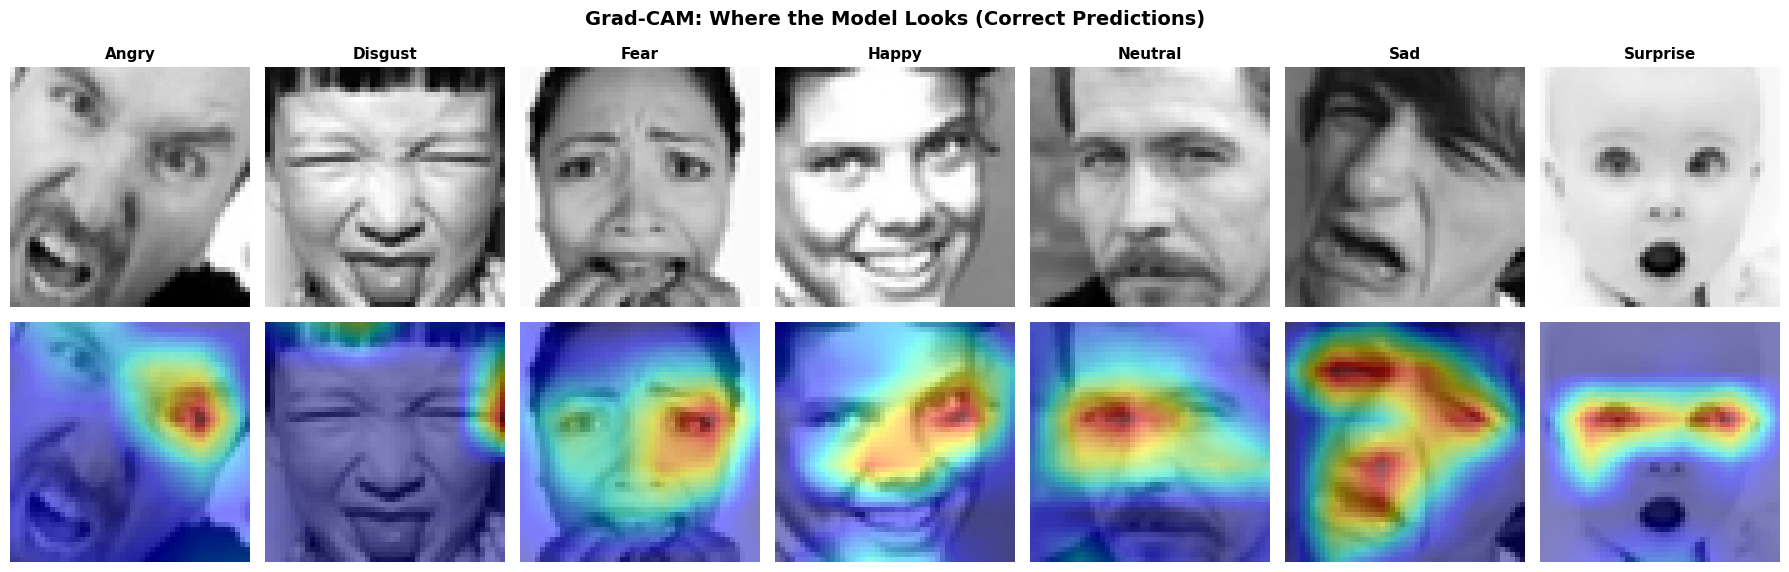


❌ GRAD-CAM: MISCLASSIFIED EXAMPLES


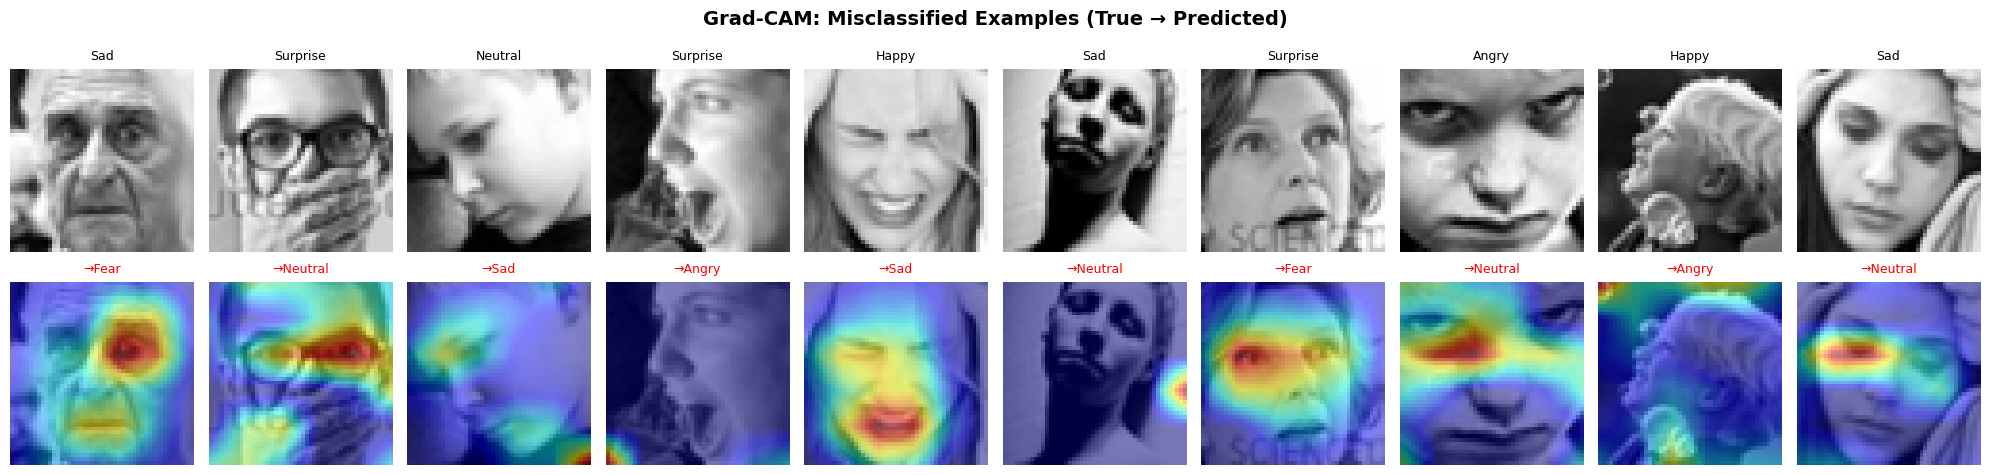


🎮 DEMO FUNCTION

✅ Demo function created: predict_emotion_demo()

USAGE:
   # From file
   emotion, conf, probs = predict_emotion_demo('path/to/image.jpg')
   
   # From array
   emotion, conf, probs = predict_emotion_demo(my_image_array)
   
   # Without Grad-CAM
   emotion, conf, probs = predict_emotion_demo(image, show_gradcam=False)


🧪 TESTING DEMO (Random test images)

Test: Happy


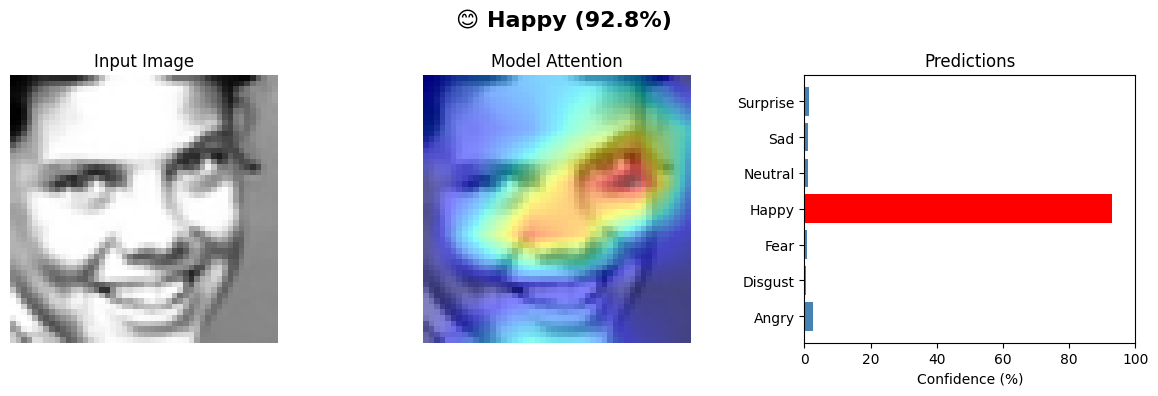


Test: Neutral


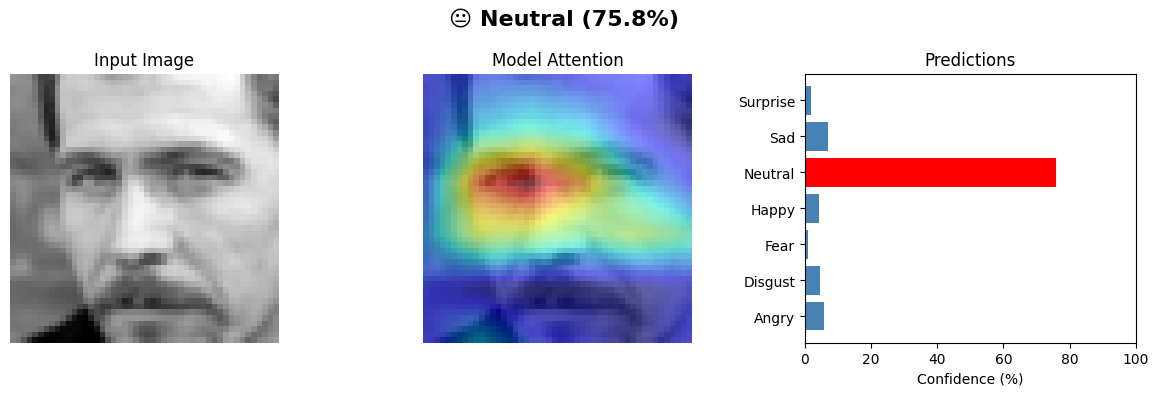


Test: Sad


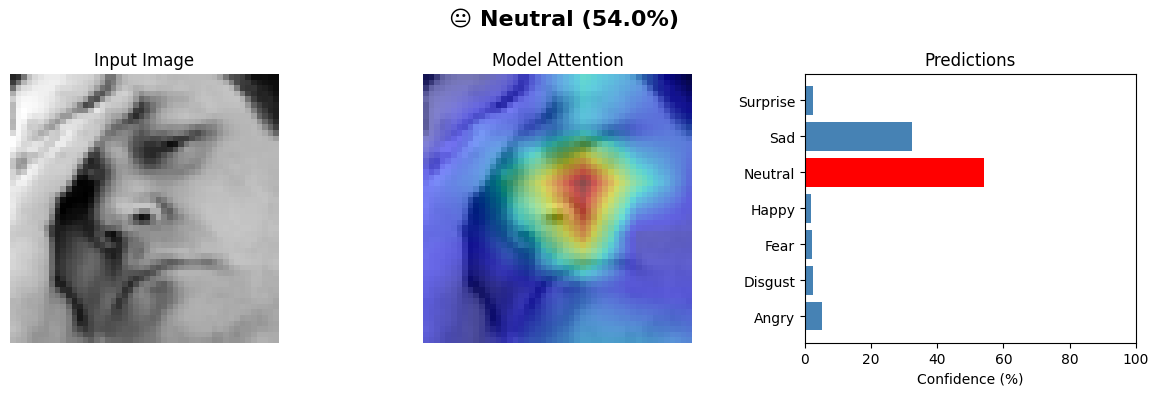


✅ CELL 9 COMPLETE!

📊 SAVED VISUALIZATIONS:
   - gradcam_correct_v2.png
   - gradcam_misclassified_v2.png
   
🎮 DEMO READY:
   Use predict_emotion_demo() to test new images!


🎉 PIPELINE COMPLETE!


In [11]:
#@title 🔬 Cell 9: Grad-CAM Visualization & Demo
"""
- Grad-CAM heatmaps showing what the model focuses on
- Demo function for testing new images
"""

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

print("=" * 60)
print("🔬 GRAD-CAM VISUALIZATION")
print("=" * 60)

# ===== PREPARE MODEL FOR GRAD-CAM =====
print("\n🔧 Preparing model for Grad-CAM...")

# Clone model without softmax for Grad-CAM
gradcam_model = tf.keras.models.clone_model(best_model)
gradcam_model.set_weights(best_model.get_weights())

gradcam = Gradcam(gradcam_model, model_modifier=ReplaceToLinear(), clone=True)
print("✅ Grad-CAM ready!")

# ===== GRAD-CAM FOR CORRECT PREDICTIONS =====
print("\n" + "=" * 60)
print("✅ GRAD-CAM: CORRECT PREDICTIONS (1 per emotion)")
print("=" * 60)

fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for idx, emotion in enumerate(TARGET_EMOTIONS):
    # Find a correct prediction for this emotion
    emotion_mask = (y_test == idx) & (y_pred == idx)
    correct_indices = np.where(emotion_mask)[0]

    if len(correct_indices) > 0:
        sample_idx = correct_indices[0]
        img = X_test[sample_idx:sample_idx+1]

        # Generate Grad-CAM
        score = CategoricalScore([idx])
        cam = gradcam(score, img, penultimate_layer=-1)

        # Original image
        axes[0, idx].imshow(img[0].squeeze(), cmap='gray')
        axes[0, idx].set_title(emotion.capitalize(), fontsize=11, fontweight='bold')
        axes[0, idx].axis('off')

        # Heatmap overlay
        axes[1, idx].imshow(img[0].squeeze(), cmap='gray')
        axes[1, idx].imshow(cam[0], cmap='jet', alpha=0.5)
        axes[1, idx].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=11)

plt.suptitle('Grad-CAM: Where the Model Looks (Correct Predictions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_correct_v2.png', dpi=150)
plt.show()

# ===== GRAD-CAM FOR MISCLASSIFIED =====
print("\n" + "=" * 60)
print("❌ GRAD-CAM: MISCLASSIFIED EXAMPLES")
print("=" * 60)

# Find misclassified
misclassified_mask = y_test != y_pred
misclassified_indices = np.where(misclassified_mask)[0]

# Random sample of misclassified
np.random.seed(42)
sample_misclassified = np.random.choice(misclassified_indices, min(10, len(misclassified_indices)), replace=False)

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, idx in enumerate(sample_misclassified):
    img = X_test[idx:idx+1]
    true_label = y_test[idx]
    pred_label = y_pred[idx]

    # Grad-CAM for predicted class
    score = CategoricalScore([pred_label])
    cam = gradcam(score, img, penultimate_layer=-1)

    # Original
    axes[0, i].imshow(img[0].squeeze(), cmap='gray')
    axes[0, i].set_title(TARGET_EMOTIONS[true_label].capitalize(), fontsize=9)
    axes[0, i].axis('off')

    # Overlay with label
    axes[1, i].imshow(img[0].squeeze(), cmap='gray')
    axes[1, i].imshow(cam[0], cmap='jet', alpha=0.5)
    axes[1, i].set_title(f'→{TARGET_EMOTIONS[pred_label].capitalize()}', fontsize=9, color='red')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('True', fontsize=10)
axes[1, 0].set_ylabel('Pred', fontsize=10)

plt.suptitle('Grad-CAM: Misclassified Examples (True → Predicted)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_misclassified_v2.png', dpi=150)
plt.show()

# ===== DEMO FUNCTION =====
print("\n" + "=" * 60)
print("🎮 DEMO FUNCTION")
print("=" * 60)

def predict_emotion_demo(image_path_or_array, show_gradcam=True):
    """
    Predict emotion from image file or numpy array.
    Shows prediction with Grad-CAM visualization.
    """
    EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
    EMOJIS = ['😠', '🤢', '😨', '😊', '😐', '😢', '😲']

    # Load and preprocess
    if isinstance(image_path_or_array, str):
        img = Image.open(image_path_or_array).convert('L')
        img = img.resize((48, 48))
        img_array = np.array(img) / 255.0
    else:
        img_array = image_path_or_array
        if img_array.max() > 1:
            img_array = img_array / 255.0

    # Ensure shape
    if len(img_array.shape) == 2:
        img_array = img_array.reshape(1, 48, 48, 1)
    elif len(img_array.shape) == 3:
        img_array = img_array.reshape(1, 48, 48, 1)

    # Predict
    pred_proba = best_model.predict(img_array, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    confidence = pred_proba[pred_class] * 100

    # Visualize
    if show_gradcam:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        # Original
        axes[0].imshow(img_array[0].squeeze(), cmap='gray')
        axes[0].set_title('Input Image', fontsize=12)
        axes[0].axis('off')

        # Grad-CAM
        score = CategoricalScore([pred_class])
        cam = gradcam(score, img_array, penultimate_layer=-1)
        axes[1].imshow(img_array[0].squeeze(), cmap='gray')
        axes[1].imshow(cam[0], cmap='jet', alpha=0.5)
        axes[1].set_title('Model Attention', fontsize=12)
        axes[1].axis('off')

        # Predictions
        colors = ['red' if i == pred_class else 'steelblue' for i in range(7)]
        bars = axes[2].barh(EMOTIONS, pred_proba * 100, color=colors)
        axes[2].set_xlabel('Confidence (%)')
        axes[2].set_xlim(0, 100)
        axes[2].set_title('Predictions', fontsize=12)

        plt.suptitle(f'{EMOJIS[pred_class]} {EMOTIONS[pred_class]} ({confidence:.1f}%)',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return EMOTIONS[pred_class], confidence, pred_proba

print("""
✅ Demo function created: predict_emotion_demo()

USAGE:
   # From file
   emotion, conf, probs = predict_emotion_demo('path/to/image.jpg')

   # From array
   emotion, conf, probs = predict_emotion_demo(my_image_array)

   # Without Grad-CAM
   emotion, conf, probs = predict_emotion_demo(image, show_gradcam=False)
""")

# ===== TEST DEMO =====
print("\n" + "=" * 60)
print("🧪 TESTING DEMO (Random test images)")
print("=" * 60)

# Test on random samples
for emotion_idx in [3, 4, 5]:  # Happy, Neutral, Sad
    sample_idx = np.where(y_test == emotion_idx)[0][0]
    print(f"\nTest: {TARGET_EMOTIONS[emotion_idx].capitalize()}")
    predict_emotion_demo(X_test[sample_idx])

print("\n" + "=" * 60)
print("✅ CELL 9 COMPLETE!")
print("=" * 60)
print("""
📊 SAVED VISUALIZATIONS:
   - gradcam_correct_v2.png
   - gradcam_misclassified_v2.png

🎮 DEMO READY:
   Use predict_emotion_demo() to test new images!
""")
print("=" * 60)
print("\n🎉 PIPELINE COMPLETE!")

In [12]:
#@title 📷 Cell 10: Webcam Demo (Real-time Emotion Detection)
"""
Capture photo from webcam and predict emotion.
Works in Google Colab using JavaScript camera capture.
"""

from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode
import cv2

print("=" * 60)
print("📷 WEBCAM EMOTION DETECTION DEMO")
print("=" * 60)

# ===== WEBCAM CAPTURE FUNCTION =====
def capture_webcam():
    """Capture image from webcam using JavaScript in Colab."""
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            div.innerHTML = '<h3>📷 Click "Capture" when ready!</h3>';
            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.width = '480px';
            video.style.height = '360px';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Capture button
            const captureButton = document.createElement('button');
            captureButton.textContent = '📸 Capture';
            captureButton.style.fontSize = '18px';
            captureButton.style.padding = '10px 30px';
            captureButton.style.margin = '10px';
            captureButton.style.cursor = 'pointer';
            div.appendChild(captureButton);

            // Wait for capture
            await new Promise((resolve) => captureButton.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)

    # Capture image
    data = eval_js('takePhoto(0.8)')

    # Decode base64
    binary = b64decode(data.split(',')[1])

    # Convert to numpy array
    jpg_array = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(jpg_array, cv2.IMREAD_COLOR)

    return img

def predict_webcam_emotion():
    """Capture from webcam and predict emotion."""
    EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
    EMOJIS = ['😠', '🤢', '😨', '😊', '😐', '😢', '😲']

    print("\n🎥 Starting webcam capture...")
    print("   (Allow camera access when prompted)\n")

    # Capture
    img = capture_webcam()

    if img is None:
        print("❌ Failed to capture image")
        return

    print("\n✅ Image captured! Processing...")

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Face detection (optional, improves accuracy)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    if len(faces) > 0:
        # Use detected face
        x, y, w, h = faces[0]
        # Add padding
        pad = int(0.1 * max(w, h))
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(gray.shape[1], x + w + pad)
        y2 = min(gray.shape[0], y + h + pad)
        face_roi = gray[y1:y2, x1:x2]
        print(f"   ✅ Face detected at ({x}, {y})")
    else:
        # Use center crop
        h, w = gray.shape
        size = min(h, w)
        y1 = (h - size) // 2
        x1 = (w - size) // 2
        face_roi = gray[y1:y1+size, x1:x1+size]
        print("   ⚠️ No face detected, using center crop")

    # Resize to 48x48
    face_resized = cv2.resize(face_roi, (48, 48))
    face_normalized = face_resized / 255.0
    face_input = face_normalized.reshape(1, 48, 48, 1)

    # Predict
    pred_proba = best_model.predict(face_input, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    confidence = pred_proba[pred_class] * 100

    # Grad-CAM
    score = CategoricalScore([pred_class])
    cam = gradcam(score, face_input, penultimate_layer=-1)

    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Original capture
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if len(faces) > 0:
        rect = plt.Rectangle((faces[0][0], faces[0][1]), faces[0][2], faces[0][3],
                             fill=False, edgecolor='lime', linewidth=2)
        axes[0].add_patch(rect)
    axes[0].set_title('Webcam Capture', fontsize=12)
    axes[0].axis('off')

    # Processed face
    axes[1].imshow(face_resized, cmap='gray')
    axes[1].set_title('Processed (48x48)', fontsize=12)
    axes[1].axis('off')

    # Grad-CAM
    axes[2].imshow(face_resized, cmap='gray')
    axes[2].imshow(cam[0], cmap='jet', alpha=0.5)
    axes[2].set_title('Model Attention', fontsize=12)
    axes[2].axis('off')

    # Predictions
    colors = ['red' if i == pred_class else 'steelblue' for i in range(7)]
    axes[3].barh(EMOTIONS, pred_proba * 100, color=colors)
    axes[3].set_xlabel('Confidence (%)')
    axes[3].set_xlim(0, 100)
    axes[3].set_title('Predictions', fontsize=12)

    plt.suptitle(f'{EMOJIS[pred_class]} {EMOTIONS[pred_class]} ({confidence:.1f}%)',
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n🎯 RESULT: {EMOJIS[pred_class]} {EMOTIONS[pred_class]} ({confidence:.1f}%)")

    return EMOTIONS[pred_class], confidence, pred_proba

# ===== RUN DEMO =====
print("""
📸 HOW TO USE:
   1. Run the cell below to start webcam
   2. Allow camera access in your browser
   3. Position your face in frame
   4. Click 'Capture' button
   5. See emotion prediction with Grad-CAM!
""")
print("=" * 60)
print("🚀 Ready! Run predict_webcam_emotion() to start!")
print("=" * 60)

📷 WEBCAM EMOTION DETECTION DEMO

📸 HOW TO USE:
   1. Run the cell below to start webcam
   2. Allow camera access in your browser
   3. Position your face in frame
   4. Click 'Capture' button
   5. See emotion prediction with Grad-CAM!

🚀 Ready! Run predict_webcam_emotion() to start!



🎥 Starting webcam capture...
   (Allow camera access when prompted)



<IPython.core.display.Javascript object>


✅ Image captured! Processing...
   ✅ Face detected at (229, 162)


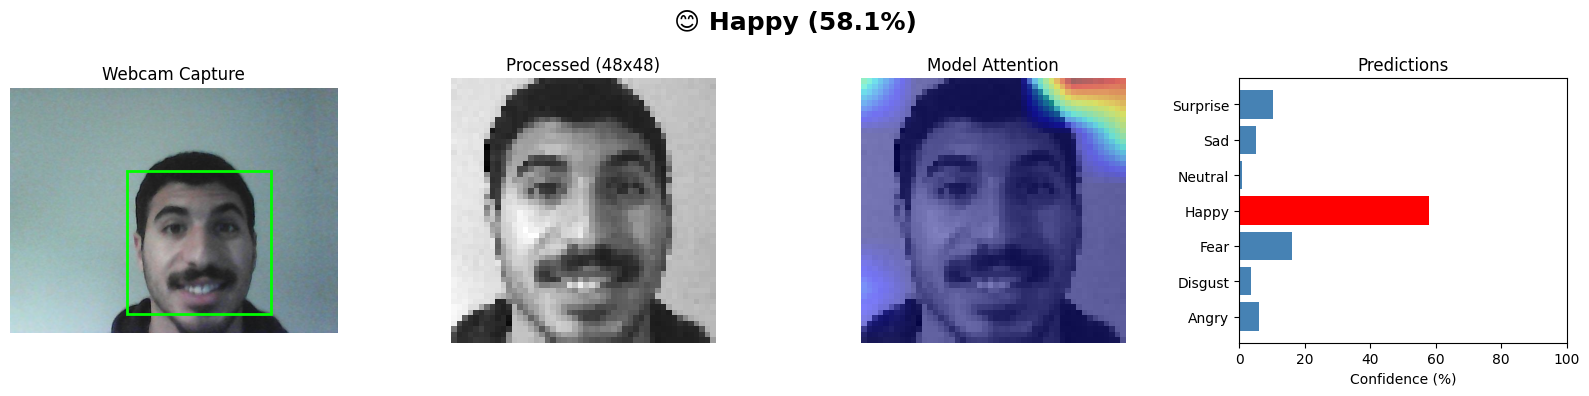


🎯 RESULT: 😊 Happy (58.1%)


In [24]:
#@title 🎥 Run Webcam Demo
# Run this cell to capture and predict!
emotion, confidence, probs = predict_webcam_emotion()